In [16]:
library(data.table)
library(dplyr)
library(ggplot2)

In [17]:
annos = fread('/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/annotate/cis_windows_to_annotate/PRDM4_cis_region_arthur_intersect.bed')
annos = fread('/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/annotate/cis_windows_to_annotate/CD4_TCM_cis_regions_arthur_intersect.bed')
colnames(annos) = c('chr','start_cis','end_cis','chr_anno','start_anno','end_anno','anno','overlap')
head(annos)

chr,start_cis,end_cis,chr_anno,start_anno,end_anno,anno,overlap
<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>
chr1,169750193,169993972,chr1,169750059,169751259,chromHMM_polycomb,1066
chr1,169750193,169993972,chr1,169750198,169750199,phyloP_2,1
chr1,169750193,169993972,chr1,169750198,169750208,phastCons_0.2,10
chr1,169750193,169993972,chr1,169750256,169750257,phyloP_2,1
chr1,169750193,169993972,chr1,169750294,169750295,phyloP_2,1
chr1,169750193,169993972,chr1,169750336,169750342,phastCons_0.2,6


In [18]:
annos=head(annos,5000)

In [19]:
nrow(annos)

[1] 5000

In [20]:
anno_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/annotate/'
annos_cat = as.data.frame(fread(paste0(anno_dir,'CWAS_categories_noncoding.bed.csv')))
head(annos_cat,2)

,ID,link,Category,NCAS,SVannotate,raw file,ref,processed,description,processing,elements,mean,median,min,max,%genome
,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>
1,z_2.18,gs://talkowski-sv-noncoding/annotations/master-bed/noncoding_z_2.18.bed,conservation/constraint,NA,x,https://storage.googleapis.com/gcp-public-data--gnomad/release/3.1/secondary_analyses/genomic_constraint/constraint_z_genome_1kb.qc.download.txt.gz,https://www.nature.com/articles/s41586-023-06045-0,x,non-coding Z >= 2.18,"x <- read.table(""""constraint_z_genome_1kb.qc.download.txt"""", header=T, sep=""""\t""""); z <- x[which(x$z >= 2.18),]; a <- z[,c(""""chrom"""", """"start"""", """"end"""", """"z"""")]; a$annotation <- """"z_2.18""""; write.table(a, """"noncoding_z_2.18.bed"""", row.names=F, col.names=F, sep=""""\t"""", quote=F)",200985,1000,1000,1000,1000,0.07
2,z_4.0,gs://talkowski-sv-noncoding/annotations/master-bed/noncoding_z_4.0.bed,conservation/constraint,NA,x,https://storage.googleapis.com/gcp-public-data--gnomad/release/3.1/secondary_analyses/genomic_constraint/constraint_z_genome_1kb.qc.download.txt.gz,https://www.nature.com/articles/s41586-023-06045-0,x,non-coding Z >= 4.0,"x <- read.table(""""constraint_z_genome_1kb.qc.download.txt"""", header=T, sep=""""\t""""); z <- x[which(x$z >= 4.0),]; a <- z[,c(""""chrom"""", """"start"""", """"end"""", """"z"""")]; a$annotation <- """"z_4.0""""; write.table(a, """"noncoding_z_4.0.bed"""", row.names=F, col.names=F, sep=""""\t"""", quote=F)",31409,1000,1000,1000,1000,0.01


In [21]:
annos_cat$anno = annos_cat$ID
annos = inner_join(annos,annos_cat[,c('anno','Category')])
head(annos)

Joining with `by = join_by(anno)`


chr,start_cis,end_cis,chr_anno,start_anno,end_anno,anno,overlap,Category
<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<chr>
chr1,169750193,169993972,chr1,169750059,169751259,chromHMM_polycomb,1066,functional
chr1,169750193,169993972,chr1,169750198,169750199,phyloP_2,1,conservation/constraint
chr1,169750193,169993972,chr1,169750198,169750208,phastCons_0.2,10,conservation/constraint
chr1,169750193,169993972,chr1,169750256,169750257,phyloP_2,1,conservation/constraint
chr1,169750193,169993972,chr1,169750294,169750295,phyloP_2,1,conservation/constraint
chr1,169750193,169993972,chr1,169750336,169750342,phastCons_0.2,6,conservation/constraint


In [22]:
unique(annos$Category)

[1] "functional"              "conservation/constraint"
[3] "gencode"

In [23]:
saige_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/'

In [24]:
celltype='CD4_TCM'

In [25]:
rare_sv_file = paste0(saige_dir,celltype,'/',celltype,'_rare_all_cis_raw_pvalues.tsv')
rare_sv_df = as.data.frame(fread(rare_sv_file))
rare_sv_df$POS = as.numeric(rare_sv_df$POS)
# df_rare = rare_sv_df[rare_sv_df$gene == gene,]

Warning message in eval(expr, envir, enclos):
“NAs introduced by coercion”


In [26]:
df_rare = rare_sv_df
df_rare$pos = df_rare$POS
df_rare$chr = paste0('chr',df_rare$CHR)

In [29]:
library(data.table)

# Convert to data.tables
snp_dt <- as.data.table(df_rare)
anno_dt <- as.data.table(annos)

# Ensure correct types
snp_dt[, chr := as.character(chr)]
snp_dt[, pos := as.integer(pos)]
snp_dt <- snp_dt[!is.na(pos)]

anno_dt[, chr := as.character(chr)]
anno_dt[, start_anno := as.integer(start_anno)]
anno_dt[, end_anno := as.integer(end_anno)]
anno_dt[, anno := as.character(anno)]
head(anno_dt)

chr,start_cis,end_cis,chr_anno,start_anno,end_anno,anno,overlap,Category
<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<chr>
chr1,169750193,169993972,chr1,169750059,169751259,chromHMM_polycomb,1066,functional
chr1,169750193,169993972,chr1,169750198,169750199,phyloP_2,1,conservation/constraint
chr1,169750193,169993972,chr1,169750198,169750208,phastCons_0.2,10,conservation/constraint
chr1,169750193,169993972,chr1,169750256,169750257,phyloP_2,1,conservation/constraint
chr1,169750193,169993972,chr1,169750294,169750295,phyloP_2,1,conservation/constraint
chr1,169750193,169993972,chr1,169750336,169750342,phastCons_0.2,6,conservation/constraint


In [30]:
# Initialize binary columns for each annotation type
for (atype in unique(anno_dt$anno)) {
  snp_dt[, (atype) := 0L]  # default: 0
}
head(snp_dt)

V1,CHR,POS,MarkerID,Allele1,Allele2,AC_Allele2,AF_Allele2,MissingRate,BETA,⋯,gencode.v39.intron.protein_coding,en4_CTCF,chromHMM_insul,z_2.18,OCRs,en4_zinc,fetal_cortex_enh_gw18,gencode.v39.exon.miscRNA,gencode.v39.gene.miscRNA,uce_primate
<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
0,1,169750193,1:169750193:A:G,A,G,26,0.006753250,0.000000000,0.0123479,⋯,0,0,0,0,0,0,0,0,0,0
1,1,169750364,1:169750364:A:G,A,G,5,0.001298700,0.000000000,-0.0224649,⋯,0,0,0,0,0,0,0,0,0,0
2,1,169750440,1:169750440:A:G,A,G,2,0.000519481,0.000000000,-0.1494250,⋯,0,0,0,0,0,0,0,0,0,0
3,1,169750931,1:169750931:T:A,T,A,2,0.000519481,0.000519481,0.0350850,⋯,0,0,0,0,0,0,0,0,0,0
4,1,169751100,1:169751100:T:C,T,C,2,0.000519481,0.000000000,-0.4510960,⋯,0,0,0,0,0,0,0,0,0,0
5,1,169751215,1:169751215:T:C,T,C,2,0.000519481,0.000000000,0.1416340,⋯,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Loop through annotation types and use fast non-equi join
for (atype in unique(annos$anno)) {
    if (!(atype %in% unique(annos_cat[annos_cat$Category == 'functional',]$anno))){next}
  anno_sub <- anno_dt[anno == atype]
  
  setkey(anno_sub, chr, start_anno, end_anno)
  
  hits <- foverlaps(
    snp_dt[, .(chr, start_anno = pos, end_anno = pos, MarkerID)],  # SNP as 1bp range
    anno_sub,
    by.x = c("chr", "start_anno", "end_anno"),
    nomatch = 0
  )
  
  snp_dt[hits, on = "MarkerID", (atype) := 1L]
}
head(snp_dt)

In [27]:
# Unique annotation types
anno_types <- unique(annos$anno)

# Copy of SNP table
snp_annotated <- df_rare
head(snp_annotated)

,V1,CHR,POS,MarkerID,Allele1,Allele2,AC_Allele2,AF_Allele2,MissingRate,BETA,⋯,Tstat,var,p.value,p.value.NA,Is.SPA,N,gene,is_snp,pos,chr
,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<int>,<chr>,<lgl>,<dbl>,<chr>
1,0,1,169750193,1:169750193:A:G,A,G,26,0.006753250,0.000000000,0.0123479,⋯,7.27645,589.2860,0.76436900,0.76436900,FALSE,1925,ENSG00000000457,TRUE,169750193,chr1
2,1,1,169750364,1:169750364:A:G,A,G,5,0.001298700,0.000000000,-0.0224649,⋯,-2.64166,117.5900,0.80753500,0.80753500,FALSE,1925,ENSG00000000457,TRUE,169750364,chr1
3,2,1,169750440,1:169750440:A:G,A,G,2,0.000519481,0.000000000,-0.1494250,⋯,-7.57592,50.7005,0.28734200,0.28734200,FALSE,1925,ENSG00000000457,TRUE,169750440,chr1
4,3,1,169750931,1:169750931:T:A,T,A,2,0.000519481,0.000519481,0.0350850,⋯,1.81045,51.6018,0.80101700,0.80101700,FALSE,1925,ENSG00000000457,TRUE,169750931,chr1
5,4,1,169751100,1:169751100:T:C,T,C,2,0.000519481,0.000000000,-0.4510960,⋯,-18.93820,41.9826,0.00346863,0.00346863,FALSE,1925,ENSG00000000457,TRUE,169751100,chr1
6,5,1,169751215,1:169751215:T:C,T,C,2,0.000519481,0.000000000,0.1416340,⋯,6.86831,48.4935,0.32398700,0.32398700,FALSE,1925,ENSG00000000457,TRUE,169751215,chr1


In [28]:
# Loop through each annotation type and add binary column
for (atype in anno_types) {
  # Subset annotation regions of this type
  anno_sub <- annos %>% filter(anno == atype)
  
  # Initialize vector for results
  snp_annotated[[atype]] <- mapply(function(chr, pos) {
    any(
      anno_sub$chr == chr & 
      anno_sub$start_anno <= pos & 
      anno_sub$end_anno >= pos
    )
  }, df_rare$chr, df_rare$pos) * 1  # convert TRUE/FALSE to 1/0
}

head(snp_annotated)

In [ ]:
snp_annotated = snp_annotated %>% mutate(significant = ifelse(-log10(p.value)>4, 1,0))
head(snp_annotated)

In [ ]:
for (atype in anno_types){
    if (!(atype %in% unique(annos_cat[annos_cat$Category == 'functional',]$anno))){next}
    df_cur = snp_annotated[,c(atype,'p.value')]
    colnames(df_cur)[1] = 'anno'
#     print(table(df_cur$anno))
    p = ggplot(df_cur, aes(x=as.factor(anno),y=-log10(p.value), fill=as.factor(anno))) 
    p = p + geom_violin() + geom_boxplot()
    p = p + theme_classic() + ylim(c(0,3))
    print(p + ggtitle(atype))
}

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


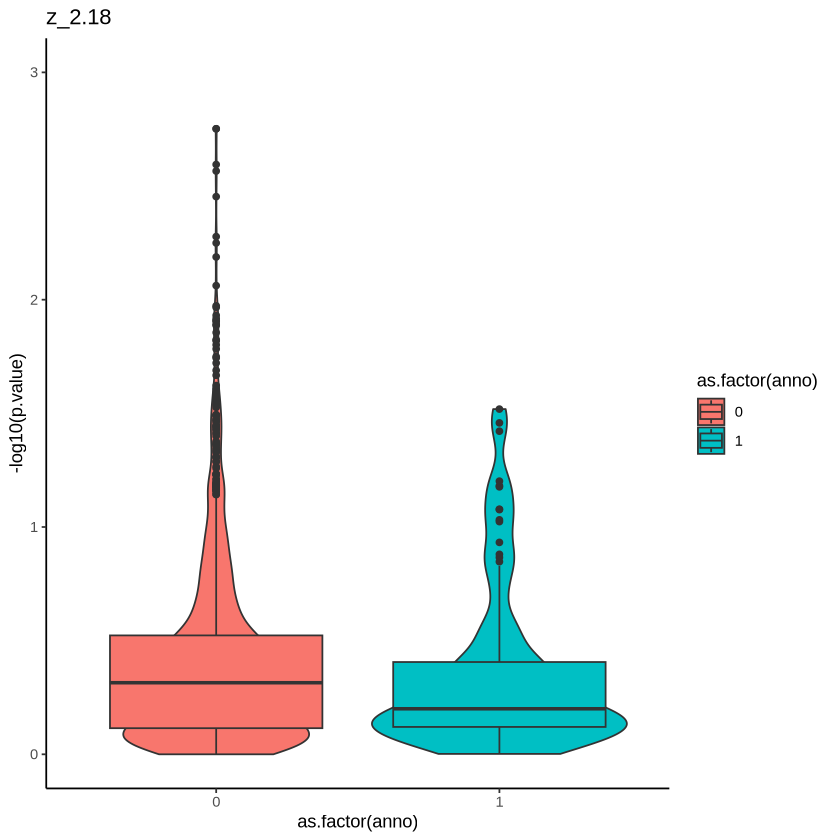

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


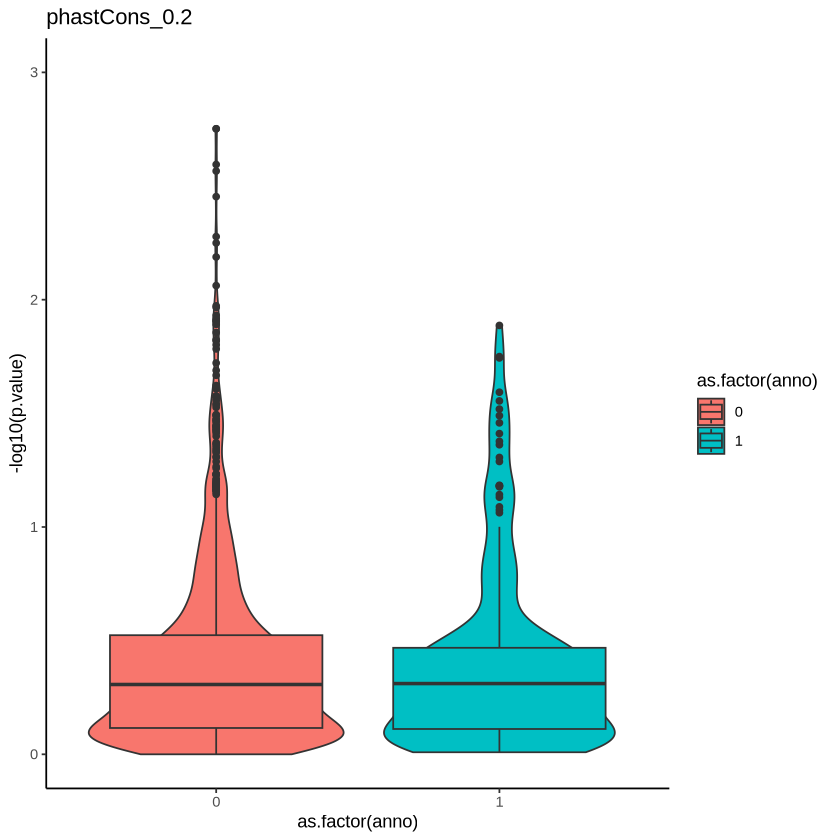

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


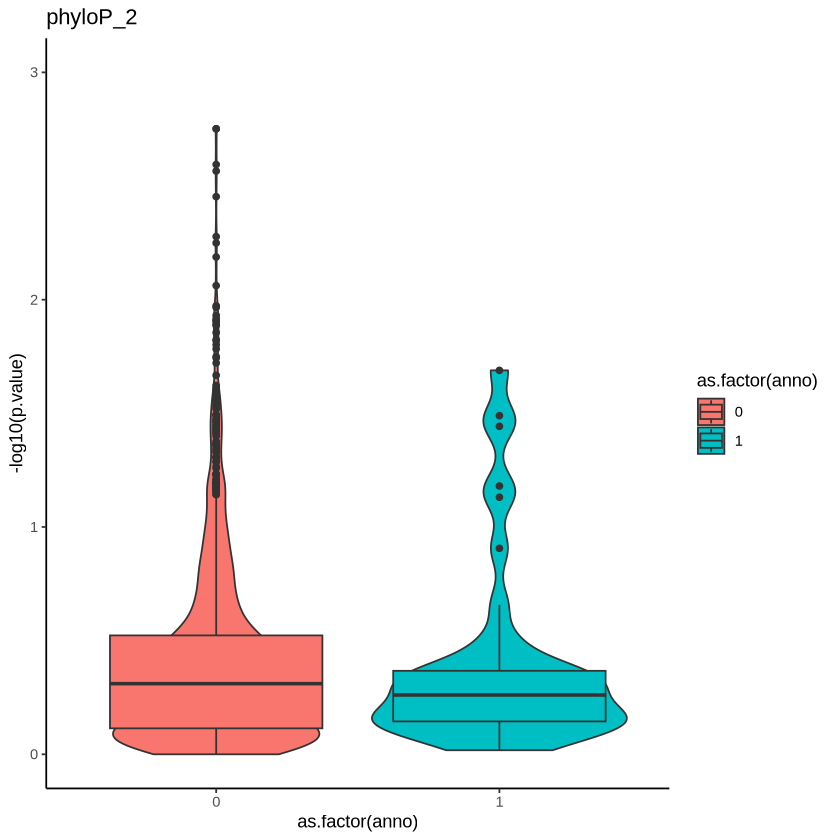

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


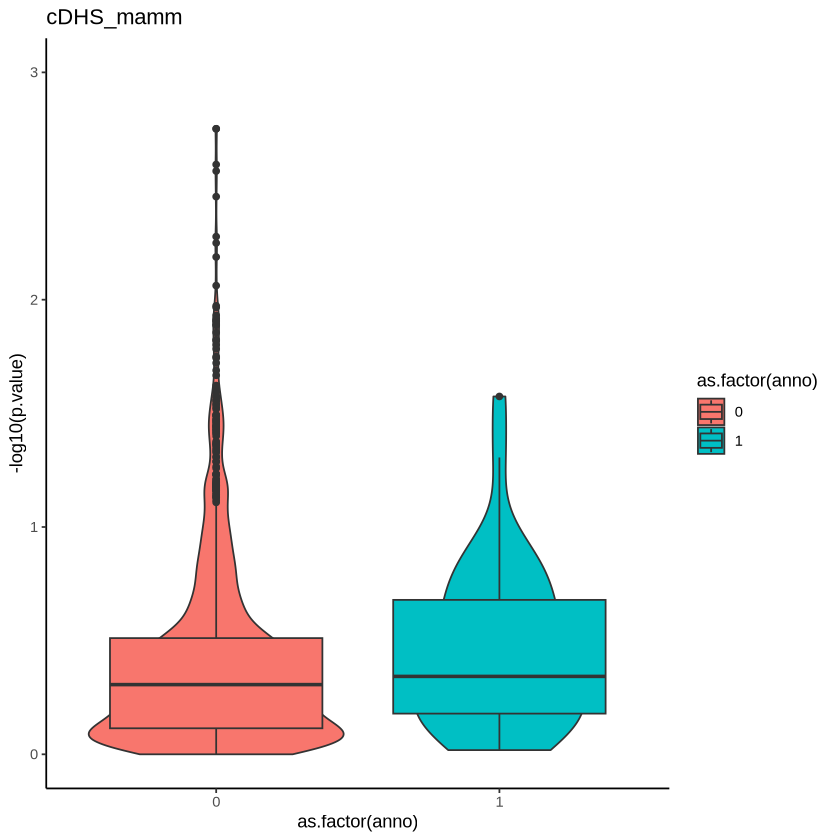

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


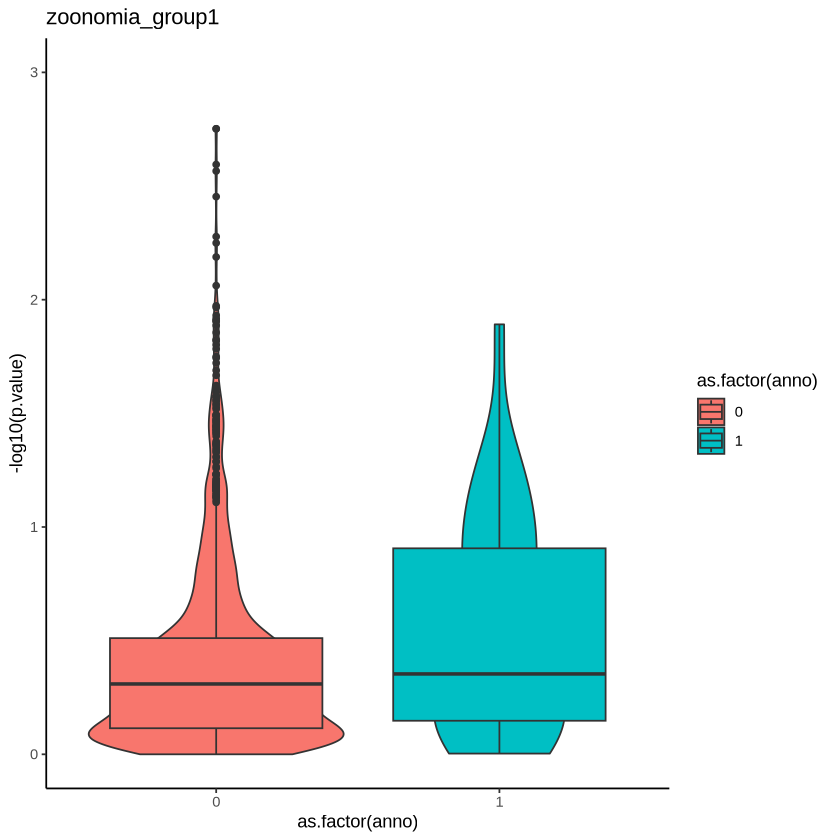

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


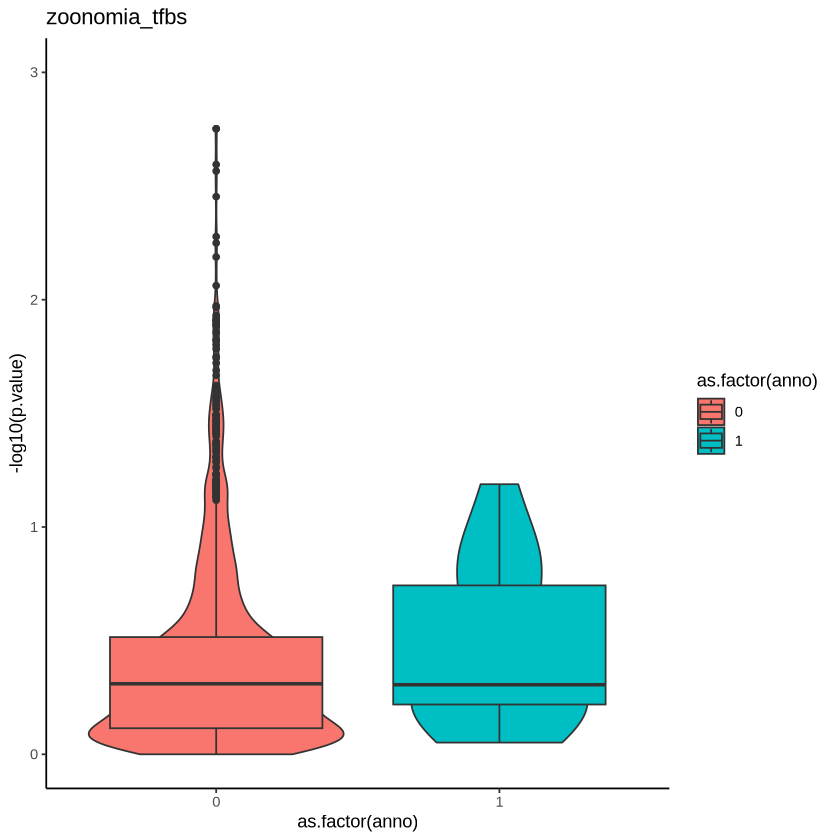

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


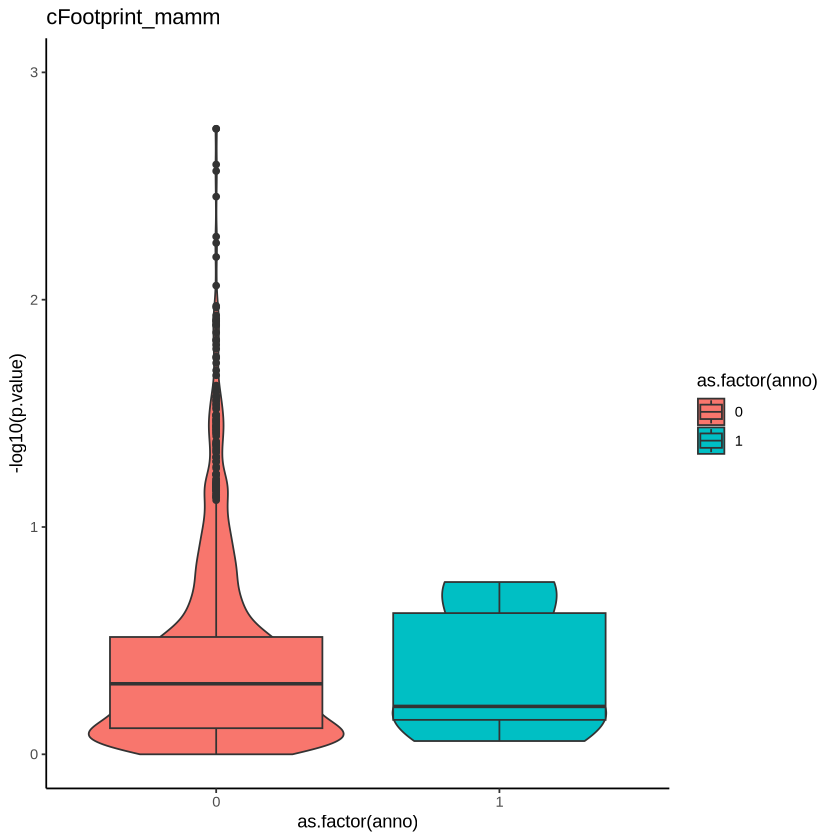

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


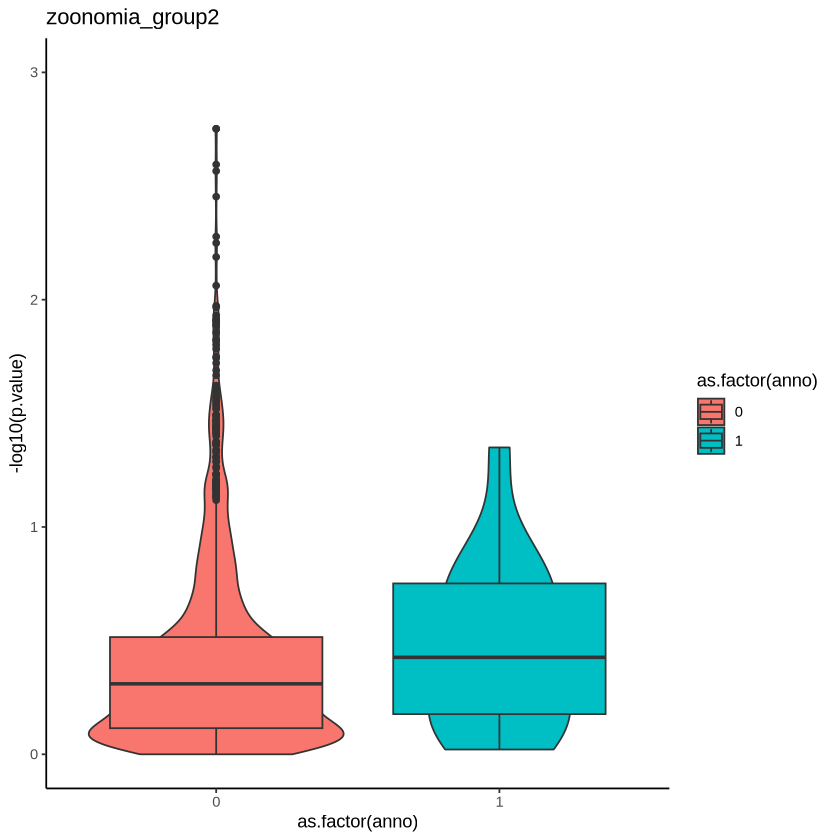

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


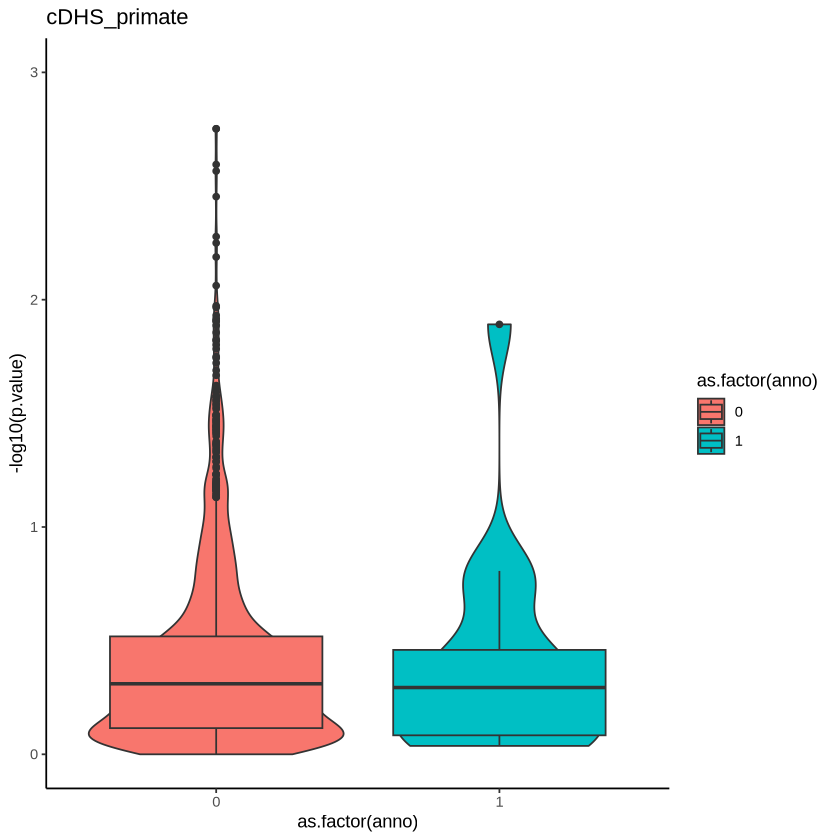

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


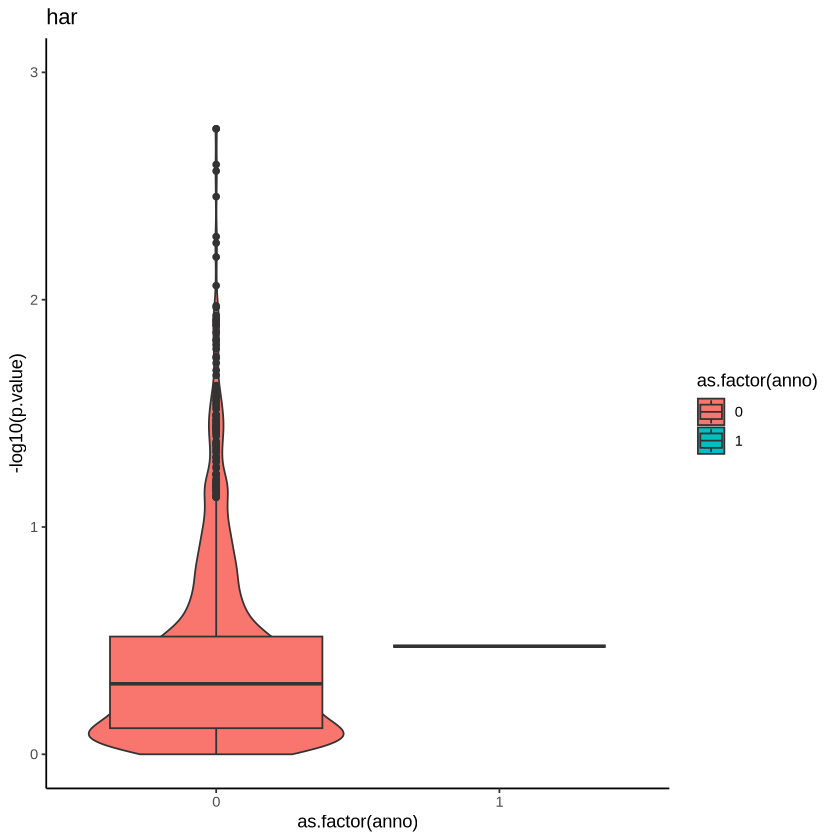

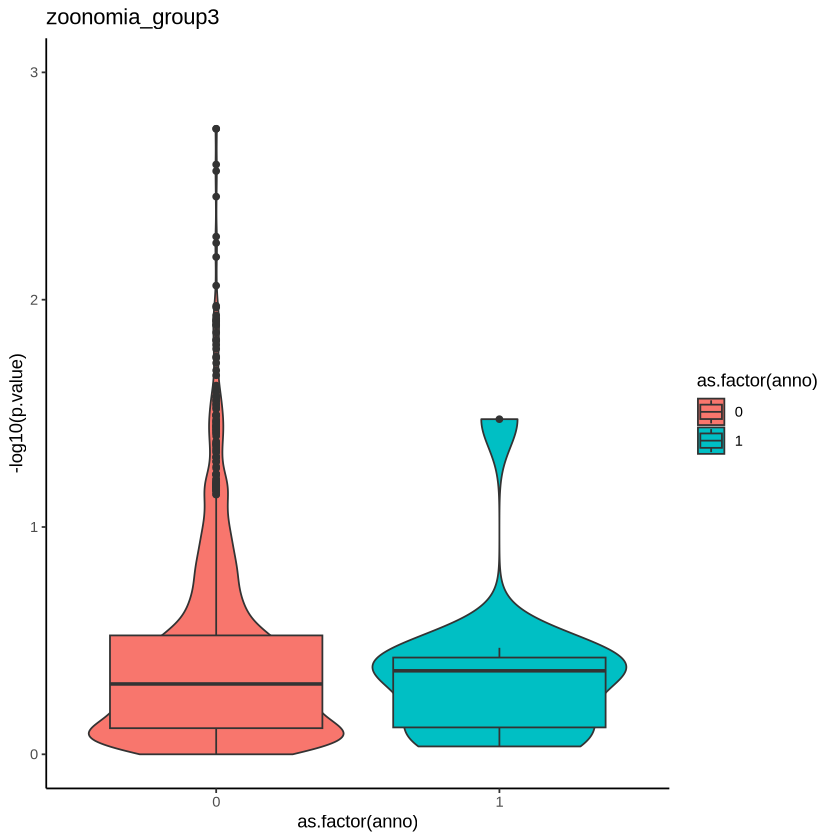

In [23]:
for (atype in anno_types){
    if (!(atype %in% unique(annos_cat[annos_cat$Category == 'conservation/constraint',]$anno))){next}
    df_cur = snp_annotated[,c(atype,'p.value')]
    colnames(df_cur)[1] = 'anno'
#     print(table(df_cur$anno))
    p = ggplot(df_cur, aes(x=as.factor(anno),y=-log10(p.value), fill=as.factor(anno))) 
    p = p + geom_violin() + geom_boxplot()
    p = p + theme_classic() + ylim(c(0,3))
    print(p + ggtitle(atype))
}

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


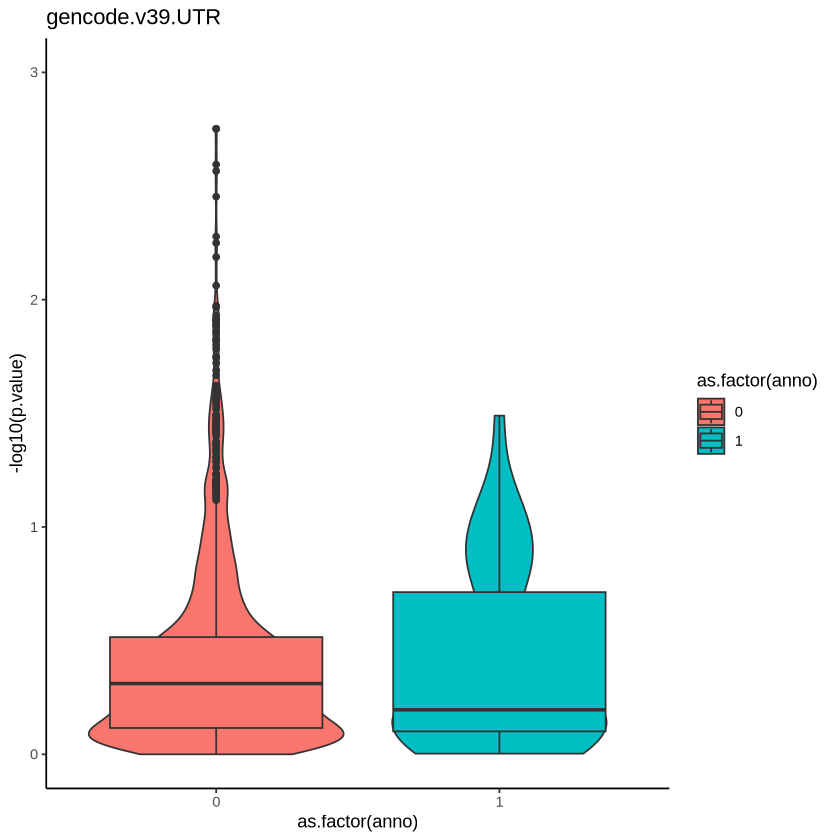

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


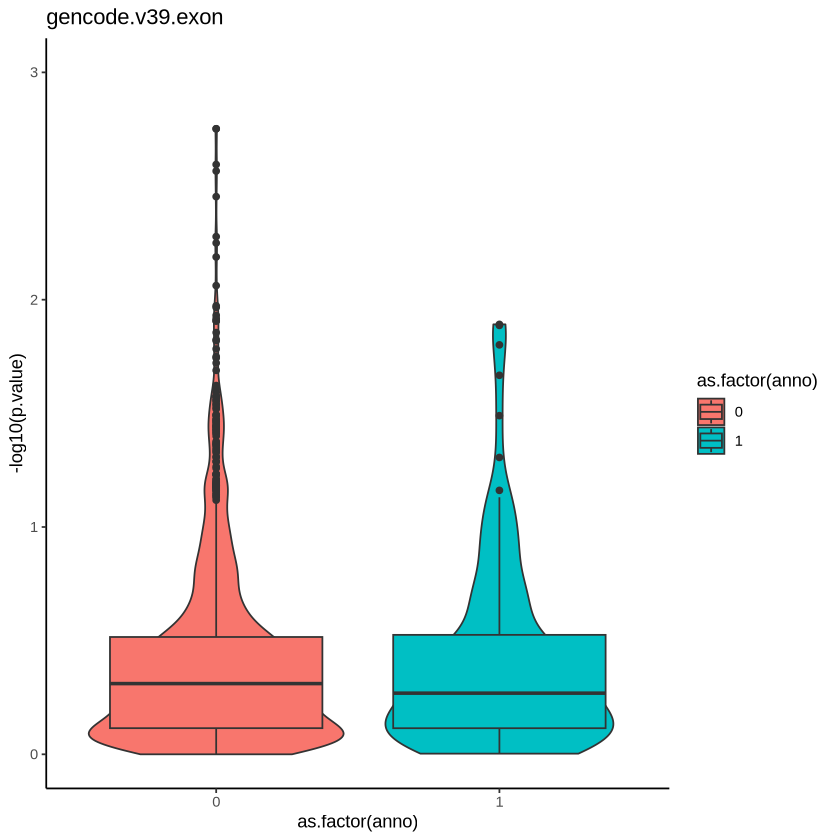

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


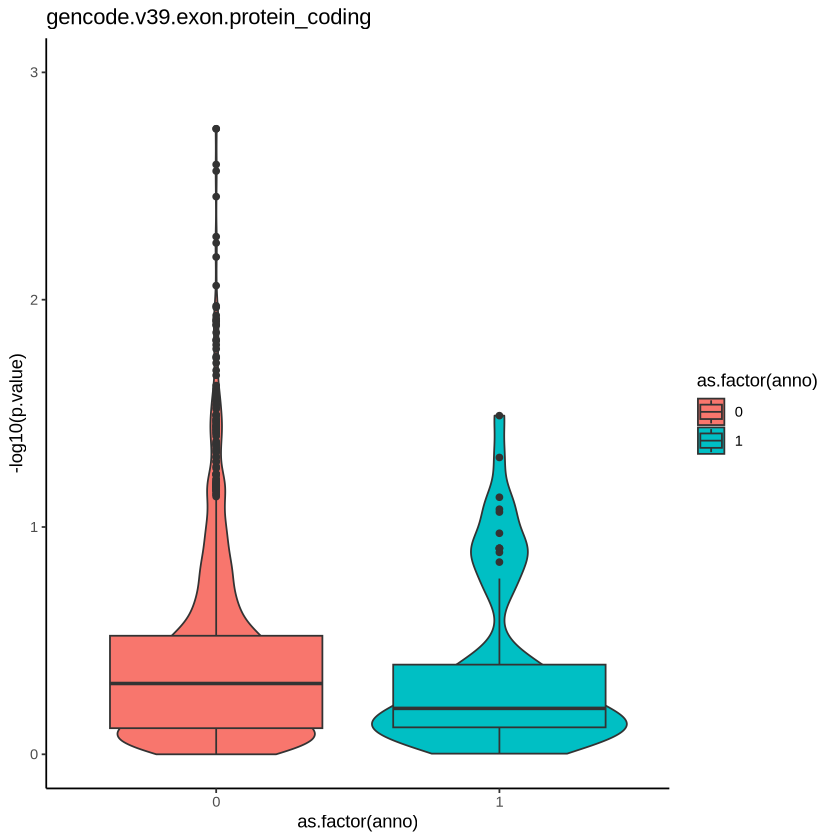

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


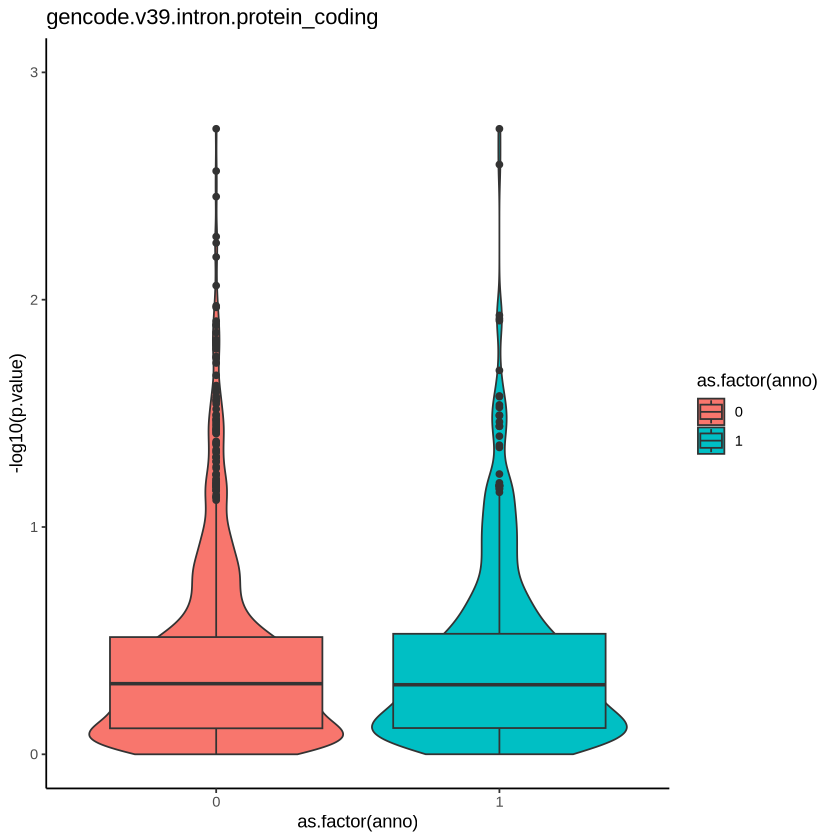

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


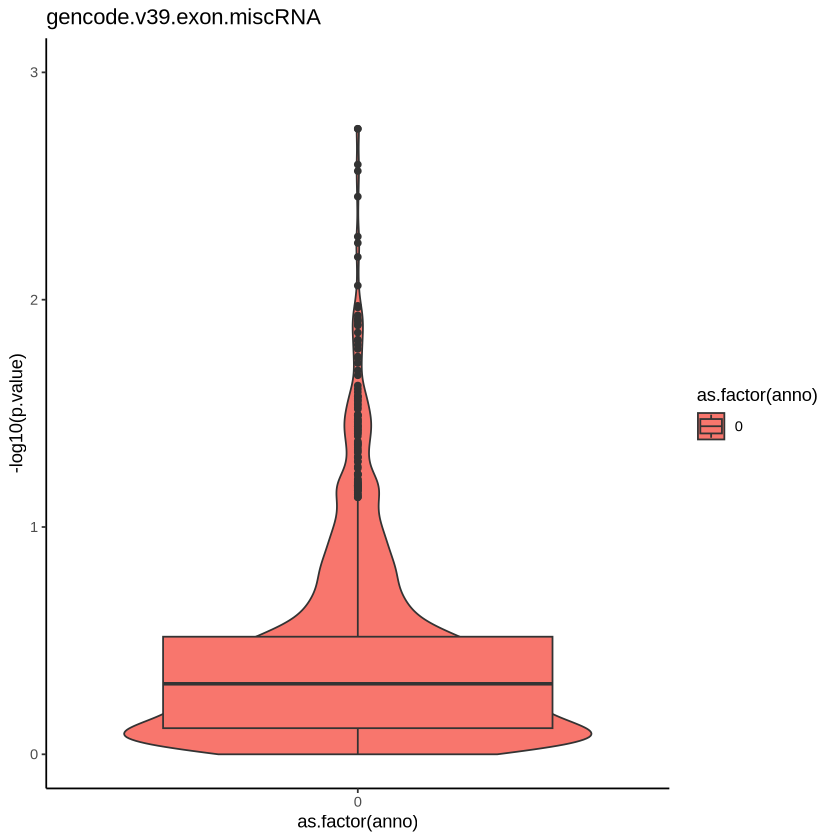

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


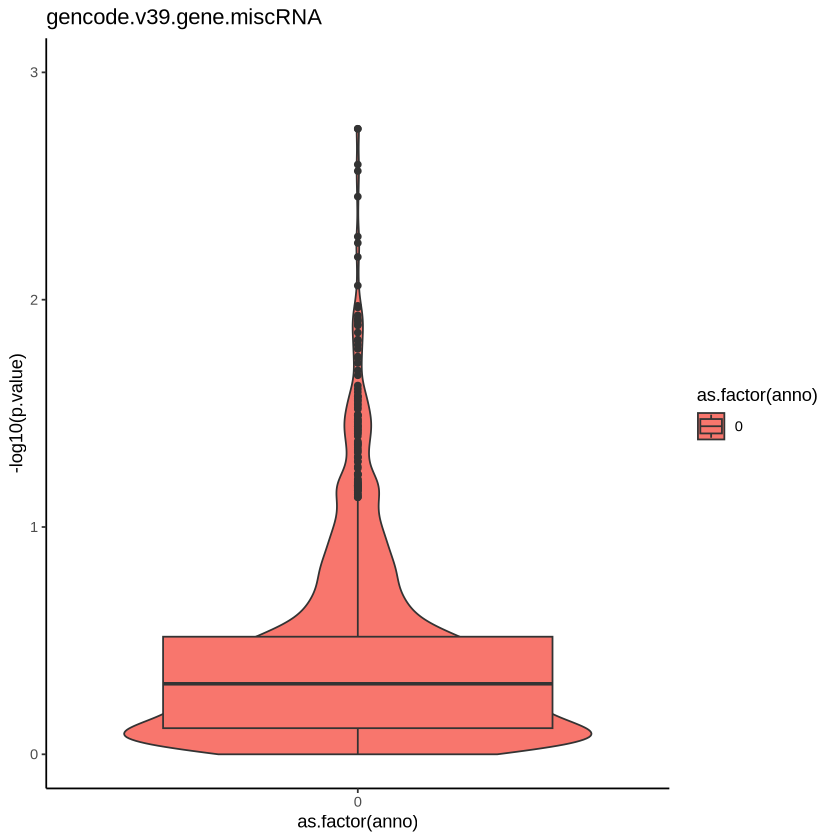

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


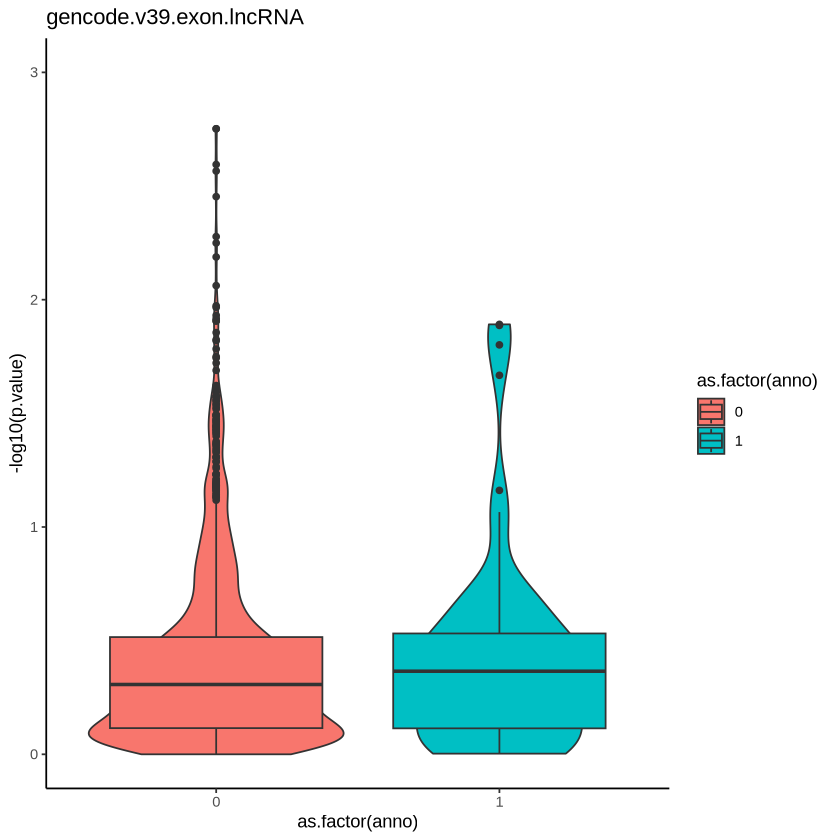

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


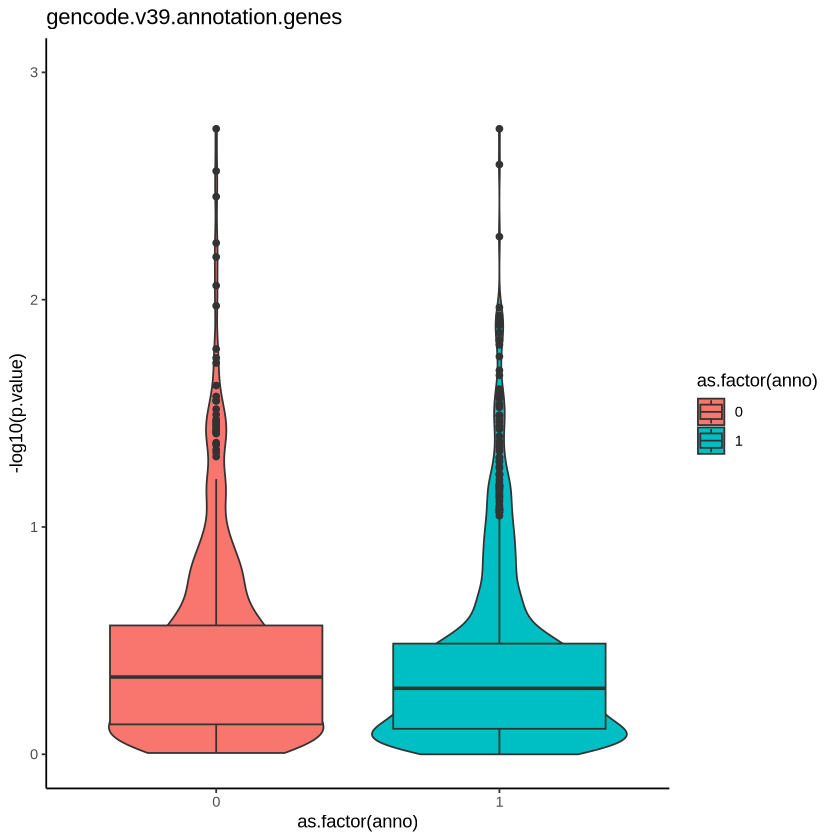

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


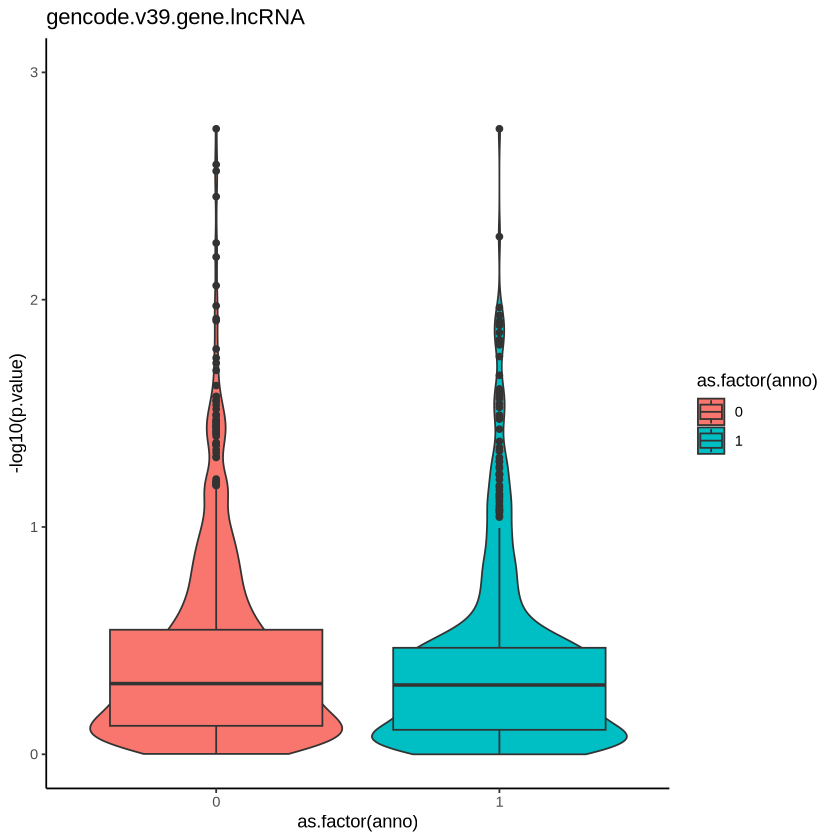

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


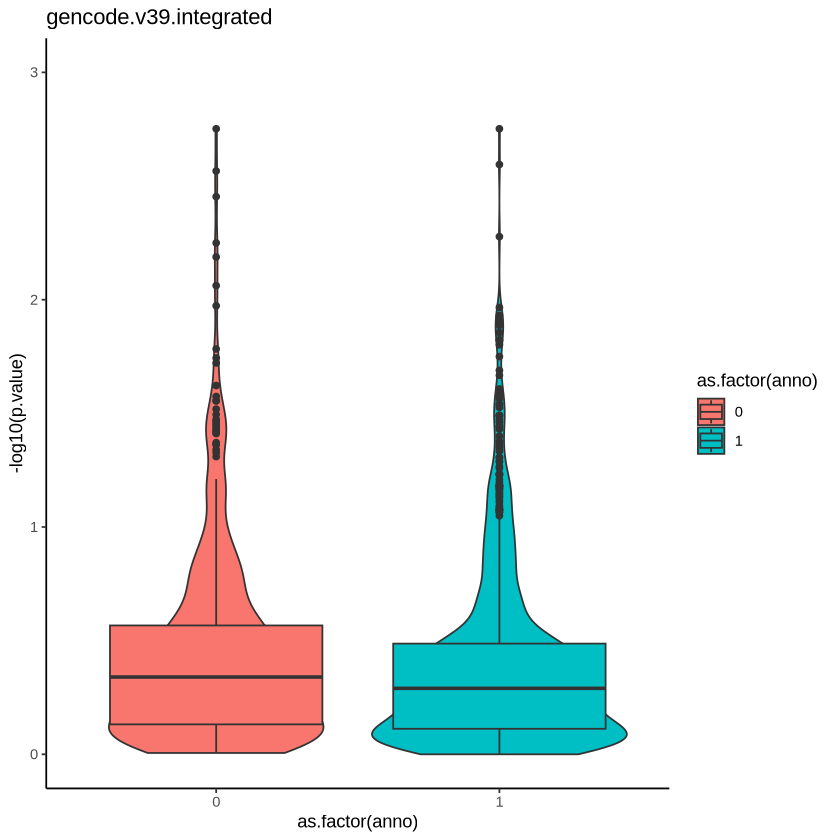

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


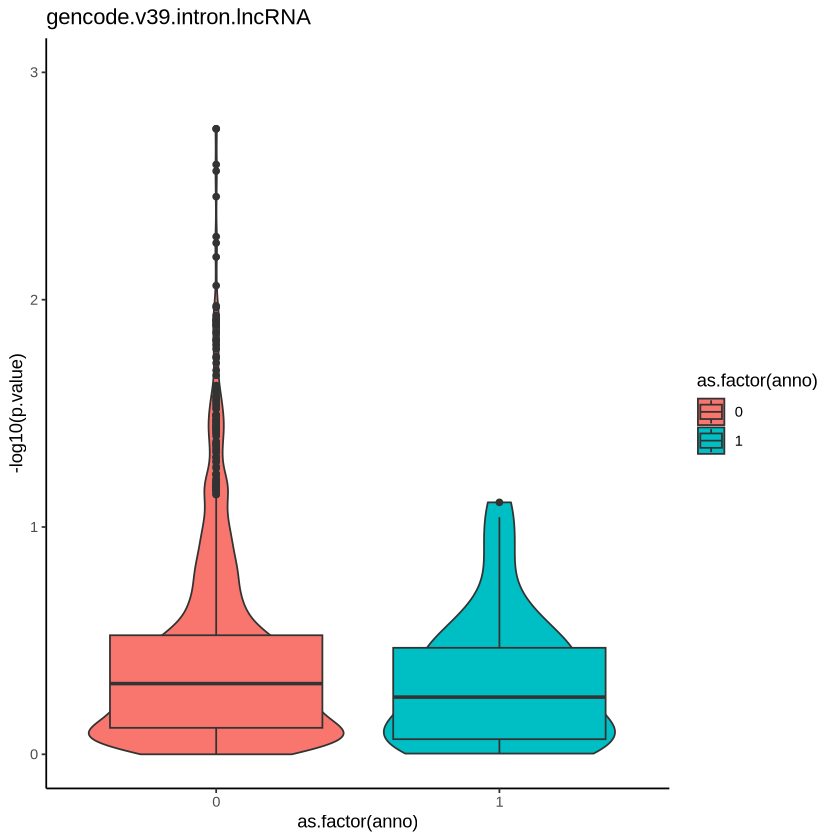

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


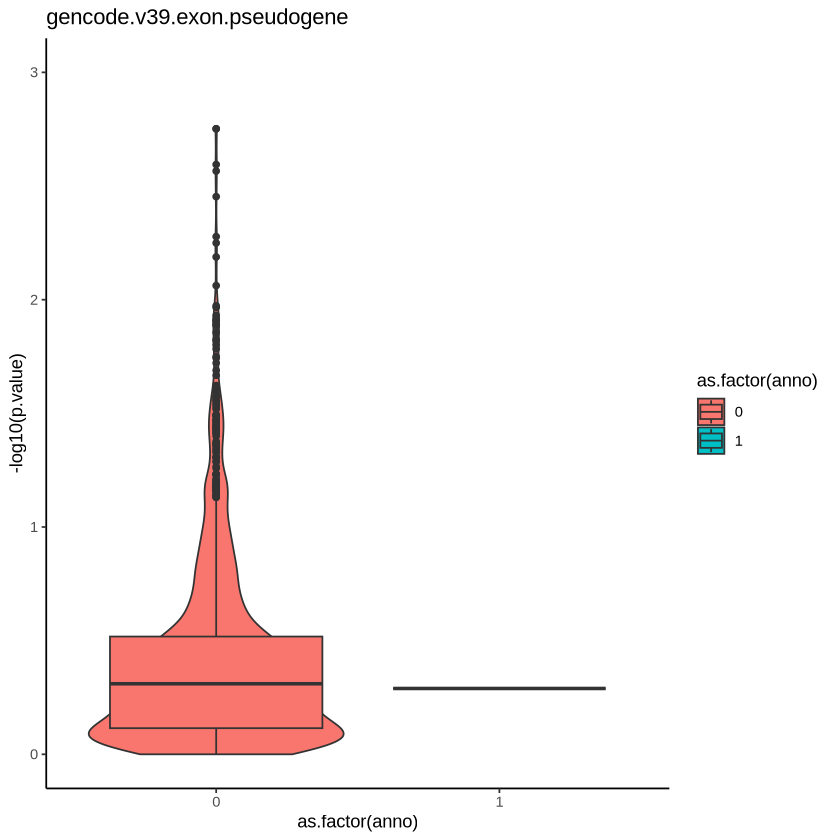

Warning message:
“Removed 16 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 16 rows containing non-finite values (`stat_boxplot()`).”


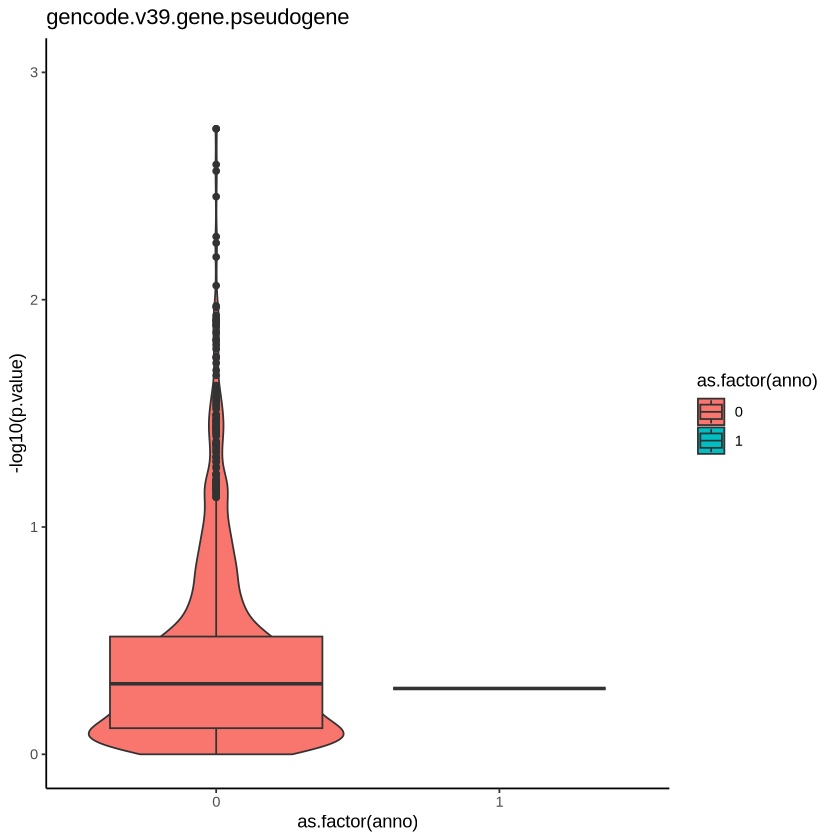

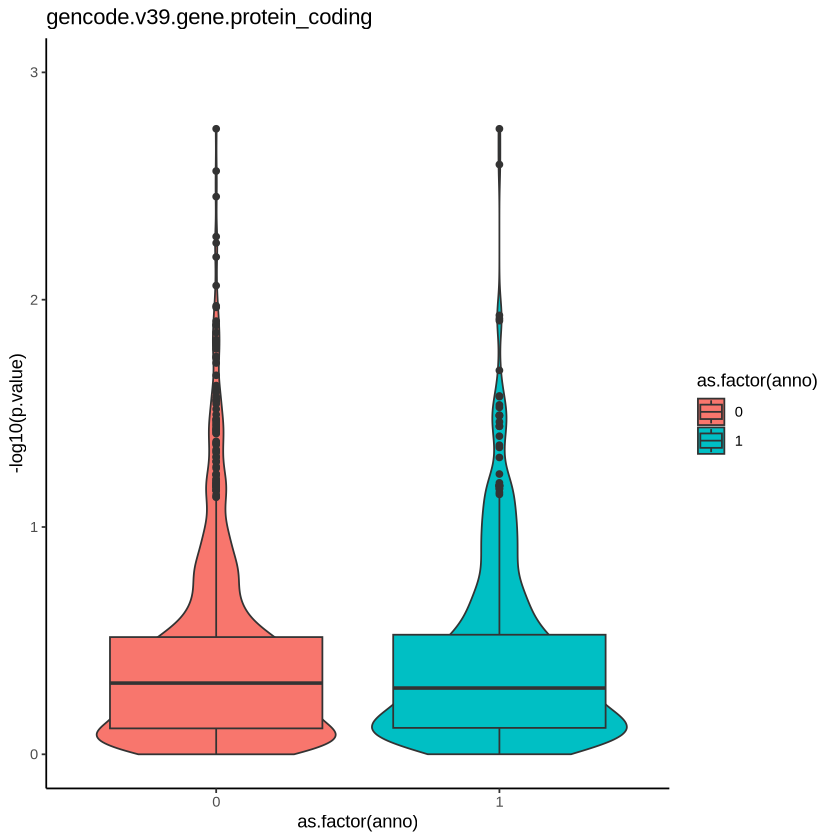

In [25]:
for (atype in anno_types){
    if (!(atype %in% unique(annos_cat[annos_cat$Category == 'gencode',]$anno))){next}
    df_cur = snp_annotated[,c(atype,'p.value')]
    colnames(df_cur)[1] = 'anno'
#     print(table(df_cur$anno))
    p = ggplot(df_cur, aes(x=as.factor(anno),y=-log10(p.value), fill=as.factor(anno))) 
    p = p + geom_violin() + geom_boxplot()
    p = p + theme_classic() + ylim(c(0,3))
    print(p + ggtitle(atype))
}

In [6]:
keep_pos = data.frame()
var_pos = df_rare[-log10(df_rare$p.value)>4,'POS']
for (pos in var_pos){
    keep_pos = rbind(keep_pos,annos[annos$start_anno <= pos & annos$end_anno >= pos,])
}
keep_pos

chr,start_cis,end_cis,chr_anno,start_anno,end_anno,anno,overlap
<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>
chr12,107632949,107861252,chr12,107693096,107696474,gencode.v39.intron.protein_coding,3378
chr12,107632949,107861252,chr12,107685799,107713162,gencode.v39.annotation.genes,27363
chr12,107632949,107861252,chr12,107685799,107713162,gencode.v39.gene.protein_coding,27363
chr12,107632949,107861252,chr12,107685799,107713162,gencode.v39.integrated,27363
chr12,107632949,107861252,chr12,107687700,107706200,en4_tx,18500
chr12,107632949,107861252,chr12,107758841,107762022,abc_0.015,3181
chr12,107632949,107861252,chr12,107759223,107762023,chromHMM_prom,2800
chr12,107632949,107861252,chr12,107759900,107761900,en4_prom,2000
chr12,107632949,107861252,chr12,107760001,107765000,TAD,4999


In [9]:
library(dplyr)

# Sample data
snp_df <- data.frame(
  snp_id = c("rs1", "rs2", "rs3"),
  chr = c("chr1", "chr1", "chr2"),
  pos = c(1000, 5000, 10000)
)

anno_df <- data.frame(
  chr = c("chr1", "chr1", "chr2", "chr2"),
  start = c(900, 4000, 9900, 12000),
  end = c(1100, 5500, 10100, 13000),
  type = c("promoter", "enhancer", "promoter", "enhancer")
)

# Unique annotation types
anno_types <- unique(anno_df$type)

# Copy of SNP table
snp_annotated <- snp_df

# Loop through each annotation type and add binary column
for (atype in anno_types) {
  # Subset annotation regions of this type
  anno_sub <- anno_df %>% filter(type == atype)
  
  # Initialize vector for results
  snp_annotated[[atype]] <- mapply(function(chr, pos) {
    any(
      anno_sub$chr == chr & 
      anno_sub$start <= pos & 
      anno_sub$end >= pos
    )
  }, snp_df$chr, snp_df$pos) * 1  # convert TRUE/FALSE to 1/0
}

print(snp_annotated)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




  snp_id  chr   pos promoter enhancer
1    rs1 chr1  1000        1        0
2    rs2 chr1  5000        0        1
3    rs3 chr2 10000        1        0
